# Rain prediction using ERA5 data

Using data from 2000-2023 from ERA5, your task is to predict whether it will rain tomorrow. This is a binary classification task. We define rainy days as days where the precipitation amount > 1 mm.

The data is already preprocessed and in tabular format. We look at five cities, which are the locations of this and last years StuMeTas.

More information about the data can be found here: [ERA5 hourly data on single levels from 1940 to present
](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview$0)


First, we install and import relevant packages.

In [ ]:
!pip -q install cdsapi xarray netCDF4 scikit-learn tensorflow openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.4/754.4 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Load/request data

Historical data: ```rain_prediction_historical.csv```

Data for training: ```rain_prediction.csv```


In [ ]:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

def fetch_weather(lat, lon, name, start="2000-01-01", end="2023-12-31"):
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start, "end_date": end,
        "daily": [
            "temperature_2m_max", "temperature_2m_min",
            "precipitation_sum", "wind_speed_10m_max",
            "pressure_msl_mean", "cloud_cover_mean",
            "relative_humidity_2m_mean", "et0_fao_evapotranspiration"
        ],
        "timezone": "UTC"
    }
    response = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)[0]
    daily = response.Daily()
    # for historical data: Only tmax, tmin, precip
    df = pd.DataFrame({
        "date":        pd.date_range(start=pd.to_datetime(daily.Time(), unit="s"), periods=daily.Variables(0).ValuesAsNumpy().shape[0], freq="D"),
        "tmax":        daily.Variables(0).ValuesAsNumpy(),
        "tmin":        daily.Variables(1).ValuesAsNumpy(),
        "precip":      daily.Variables(2).ValuesAsNumpy(),
        "wind_speed":  daily.Variables(3).ValuesAsNumpy(),
        "pressure":    daily.Variables(4).ValuesAsNumpy(),
        "cloud_cover": daily.Variables(5).ValuesAsNumpy(),
        "humidity":    daily.Variables(6).ValuesAsNumpy(),
        "et0":         daily.Variables(7).ValuesAsNumpy(),
    })
    df["location"] = name
    return df

locations = {
    "Hamburg": (53.55, 10.00),
    "Karlsruhe": (49.10, 8.24),
    "Leipzig": (51.20, 12.22),
    "Innsbruck": (47.16, 11.24),
    "Berlin": (52.31, 13.24),
}

all_data = pd.concat([fetch_weather(lat, lon, name) for name, (lat, lon) in locations.items()])
all_data.to_csv("rain_prediction.csv", index=False)

In [ ]:
# Load data from files
historical_data = pd.read_csv("rain_prediction_historical.csv", parse_dates=["date"])
data            = pd.read_csv("rain_prediction.csv", parse_dates=["date"])

## Inspect historical data

To start, we look at the historical data and compare this with statistical values (see below for the different cities, Karlsruhe is not available) to validate our data. For the comparison, it is sufficient to look at only one or two of the cities.

* [Hamburg](https://worldweather.wmo.int/en/city.html?cityId=55$0)

* [Leipzig](https://worldweather.wmo.int/en/city.html?cityId=1350$0)

* [Innsbruck](https://worldweather.wmo.int/en/city.html?cityId=905$0)

* [Berlin](https://worldweather.wmo.int/en/city.html?cityId=59$0)

In [ ]:
print(historical_data.head())
print(historical_data.groupby("location")["precip"].describe())

        date     tmax       tmin  precip location
0 1971-01-01  -5.4475 -14.247499     1.3  Hamburg
1 1971-01-02  -4.6475  -7.797500     0.0  Hamburg
2 1971-01-03  -7.0475 -13.447500     0.0  Hamburg
3 1971-01-04 -11.2975 -18.197500     0.0  Hamburg
4 1971-01-05  -5.2975 -12.147500     0.0  Hamburg
             count      mean       std  min  25%  50%       75%        max
location                                                                  
Berlin     10958.0  1.638657  3.168713  0.0  0.0  0.2  2.000000  70.000015
Hamburg    10958.0  1.990026  3.417803  0.0  0.0  0.3  2.700000  52.700000
Innsbruck  10958.0  4.628363  6.987634  0.0  0.0  1.4  6.800001  98.599990
Karlsruhe  10958.0  2.020725  3.792181  0.0  0.0  0.2  2.500000  56.600002
Leipzig    10958.0  1.769985  3.412554  0.0  0.0  0.3  2.175000  53.900005


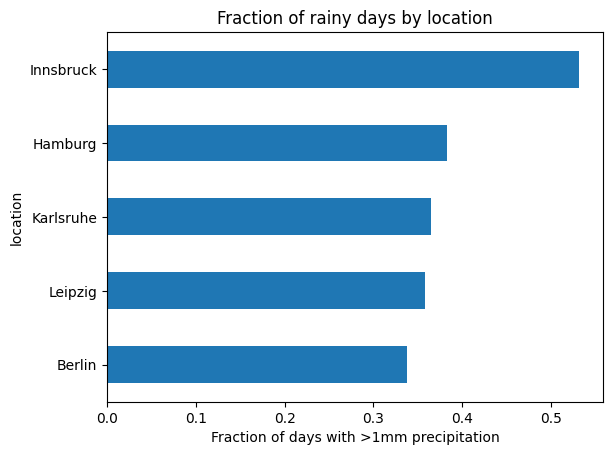

In [ ]:
# How often does it rain in each city?
historical_data["rain_today"] = (historical_data["precip"] > 1.0).astype(int)
historical_data.groupby("location")["rain_today"].mean().sort_values().plot(kind="barh")
plt.title("Fraction of rainy days by location")
plt.xlabel("Fraction of days with >1mm precipitation")
plt.show()


In [ ]:
# Select the data for one city
historical_data_hamburg = historical_data[historical_data["location"] == 'Hamburg']

In [ ]:
historical_data_hamburg

,date,tmax,tmin,precip,location,rain_today
0,1971-01-01,-5.4475,-14.247499,1.3,Hamburg,1
1,1971-01-02,-4.6475,-7.797500,0.0,Hamburg,0
2,1971-01-03,-7.0475,-13.447500,0.0,Hamburg,0
3,1971-01-04,-11.2975,-18.197500,0.0,Hamburg,0
4,1971-01-05,-5.2975,-12.147500,0.0,Hamburg,0
...,...,...,...,...,...,...
10953,2000-12-27,-0.4475,-2.047500,1.0,Hamburg,0
10954,2000-12-28,0.5025,-0.397500,1.8,Hamburg,1
10955,2000-12-29,1.0025,-1.397500,0.6,Hamburg,0
10956,2000-12-30,0.5525,-0.797500,1.4,Hamburg,1


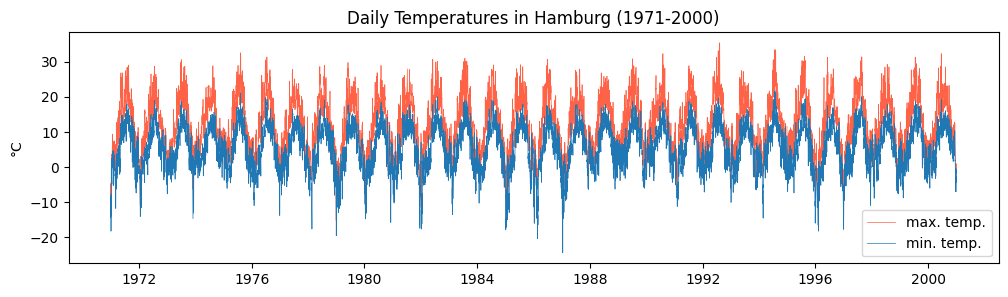

In [ ]:
# Plot temperature over time
plt.figure(figsize=(12, 3))
plt.plot(historical_data_hamburg['date'], historical_data_hamburg['tmax'], linewidth=0.5, color='tomato', label="max. temp.")
plt.plot(historical_data_hamburg['date'], historical_data_hamburg['tmin'], linewidth=0.5, label="min. temp.")
plt.legend(loc="best")
plt.title('Daily Temperatures in Hamburg (1971-2000)')
plt.ylabel('°C')
plt.show()



In [ ]:
# Mean monthly rainfall
monthly_total_rainfall = (
    historical_data_hamburg.groupby([
        historical_data_hamburg["date"].dt.year,
        historical_data_hamburg["date"].dt.month
    ])["precip"]
    .sum()
)
mean_monthly_rainfall = monthly_total_rainfall.groupby(level=1).mean()
print(mean_monthly_rainfall)

date
1     59.070000
2     40.536666
3     59.233334
4     54.156667
5     65.636667
6     76.663333
7     74.216667
8     65.970000
9     59.040000
10    54.850000
11    53.866667
12    63.650000
Name: precip, dtype: float64


In [ ]:
# Mean number of rainy days
rainy_days = (historical_data_hamburg["precip"] > 1.0).astype(int)

monthly_rainy_days = (
    rainy_days.groupby([
        historical_data_hamburg["date"].dt.year,
        historical_data_hamburg["date"].dt.month
    ])
    .sum()
)
mean_rainy_days = monthly_rainy_days.groupby(level=1).mean()
print(mean_rainy_days)

date
1     12.200000
2      9.500000
3     12.566667
4     11.700000
5     11.400000
6     13.033333
7     12.266667
8     11.300000
9     11.400000
10    10.900000
11    11.433333
12    12.200000
Name: precip, dtype: float64


In [ ]:
# Mean daily minimum temperature
monthly_mean_daily_min_temp = (
    historical_data_hamburg.groupby(historical_data_hamburg["date"].dt.month)["tmin"]
    .mean()
)
print(monthly_mean_daily_min_temp)

date
1     -1.475134
2     -1.338479
3      0.791210
4      2.978278
5      7.524973
6     10.784611
7     12.990081
8     12.961479
9     10.282000
10     6.630296
11     2.671056
12     0.108091
Name: tmin, dtype: float64


In [ ]:
# Mean daily maximum temperature
monthly_mean_daily_max_temp = (
    historical_data_hamburg.groupby(historical_data_hamburg["date"].dt.month)["tmax"]
    .mean()
)
print(monthly_mean_daily_max_temp)

date
1      2.912285
2      4.068656
3      7.660941
4     11.693889
5     16.777016
6     19.181611
7     21.101909
8     21.160457
9     17.146222
10    12.504651
11     6.982611
12     4.039919
Name: tmax, dtype: float64




---



## Data preparation

Now, we start to work with the data for training the ML models, ```rain_prediction.csv```. First, we create the labels. For this, we create a new column ```rain_today``` that contains an identifier for rain or no rain (1: precip > 1 mm, 0: precip $\leq$ 1 mm). Then, we obtain the label by creating a second column ```rain_tomorrow``` by shifting the content of ```rain_today``` by one day.



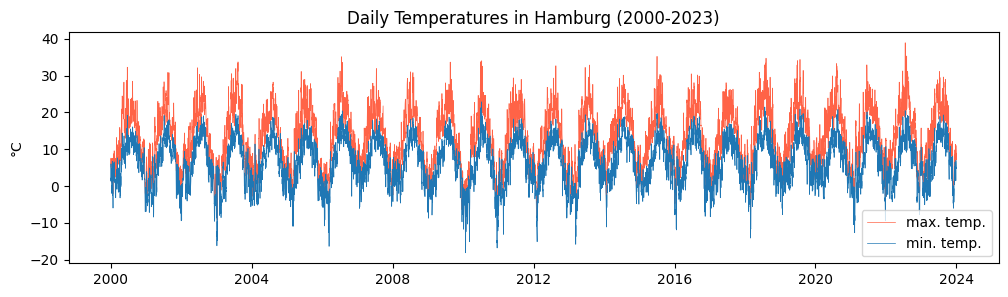

In [ ]:
# Plot temperature over time (just for visualization)
plt.figure(figsize=(12, 3))
plt.plot(data[data["location"] == 'Hamburg']['date'], data[data["location"] == 'Hamburg']['tmax'], linewidth=0.5, color='tomato', label="max. temp.")
plt.plot(data[data["location"] == 'Hamburg']['date'], data[data["location"] == 'Hamburg']['tmin'], linewidth=0.5, label="min. temp.")
plt.legend(loc="best")
plt.title('Daily Temperatures in Hamburg (2000-2023)')
plt.ylabel('°C')
plt.show()



In [ ]:
# Create column for rain/no rain
data["rain_today"] = (data["precip"] > 1.0).astype(int)
data

,date,tmax,tmin,precip,wind_speed,pressure,cloud_cover,humidity,et0,location,rain_today
0,2000-01-01,5.1525,2.1025,2.3,16.363178,1021.29590,87.500000,95.138725,0.120699,Hamburg,1
1,2000-01-02,6.2525,1.3025,0.1,18.947083,1025.15860,97.291664,97.882820,0.119071,Hamburg,0
2,2000-01-03,7.5525,6.0025,3.1,23.688984,1018.77905,100.000000,94.754850,0.200139,Hamburg,1
3,2000-01-04,7.0025,2.1525,5.0,27.009598,1013.42926,96.625000,93.494450,0.242820,Hamburg,1
4,2000-01-05,5.8025,1.8525,0.7,30.018473,1016.87090,56.875000,84.278660,0.477729,Hamburg,0
...,...,...,...,...,...,...,...,...,...,...,...
43825,2023-12-27,5.7000,1.9500,0.0,20.548400,1019.51245,70.250000,83.142660,0.455005,Berlin,0
43826,2023-12-28,10.1000,6.3000,0.2,23.557316,1011.68353,89.708336,69.455830,1.308575,Berlin,0
43827,2023-12-29,10.6000,7.5000,2.7,27.257967,1007.11670,89.750000,77.125950,1.059881,Berlin,1
43828,2023-12-30,8.3500,4.8500,2.8,27.098220,1010.92505,80.500000,82.354290,0.548122,Berlin,1


In [ ]:
data = data.sort_values(["location", "date"])

# Create label
data["rain_tomorrow"] = data.groupby("location")["rain_today"].shift(-1)

In [ ]:
# Add date information
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.dayofyear
data

,date,tmax,tmin,precip,wind_speed,pressure,cloud_cover,humidity,et0,location,rain_today,rain_tomorrow,year,month,day
35064,2000-01-01,3.3565,-0.0935,2.2,12.889810,1022.66254,99.333336,94.729950,0.162606,Berlin,1,0.0,2000,1,1
35065,2000-01-02,4.2065,2.7065,0.0,15.941944,1026.53770,99.208336,92.261100,0.204654,Berlin,0,0.0,2000,1,2
35066,2000-01-03,6.0565,4.2565,0.0,20.073025,1022.48750,99.916664,84.888660,0.448152,Berlin,0,1.0,2000,1,3
35067,2000-01-04,5.9565,4.2065,3.9,20.929594,1016.33760,100.000000,87.757355,0.377330,Berlin,1,0.0,2000,1,4
35068,2000-01-05,6.7565,0.2065,0.7,26.478973,1018.75000,53.000000,82.044266,0.540544,Berlin,0,0.0,2000,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26293,2023-12-27,7.9000,0.9000,0.0,20.767975,1020.19170,87.416664,81.302086,0.587136,Leipzig,0,0.0,2023,12,361
26294,2023-12-28,10.7500,7.5500,0.0,24.522314,1014.53320,83.000000,66.848990,1.424219,Leipzig,0,0.0,2023,12,362
26295,2023-12-29,11.2500,7.5000,0.0,30.599998,1010.25830,93.791664,70.264190,1.481963,Leipzig,0,0.0,2023,12,363
26296,2023-12-30,9.4500,4.7500,0.4,25.922500,1013.12500,83.416664,77.381460,0.920441,Leipzig,0,0.0,2023,12,364


### Data splitting into training/validation/test sets

In [170]:
# Split by time to avoid temporal autocorrelation
# Select the years 2000-2015 for training, 2016-2019 for validation and 2020-2023 for testing
data_train = data[(data["year"] < 2016)]
data_val = data[(data["year"] >= 2016) & (data["year"] <= 2019)]
data_test = data[(data["year"] >= 2020)]
print(f"NaNs: \nTraining: \n{data_train.isna().sum()} \nValidation: \n{data_val.isna().sum()} \nTest: \n{data_test.isna().sum()}")
data_train = data_train.dropna()
data_val = data_val.dropna()
data_test = data_test.dropna()

NaNs: 
Training: 
date             0
tmax             0
tmin             0
precip           0
wind_speed       0
pressure         0
cloud_cover      0
humidity         0
et0              0
location         0
rain_today       0
rain_tomorrow    0
year             0
month            0
day              0
dtype: int64 
Validation: 
date             0
tmax             0
tmin             0
precip           0
wind_speed       0
pressure         0
cloud_cover      0
humidity         0
et0              0
location         0
rain_today       0
rain_tomorrow    0
year             0
month            0
day              0
dtype: int64 
Test: 
date             0
tmax             0
tmin             0
precip           0
wind_speed       0
pressure         0
cloud_cover      0
humidity         0
et0              0
location         0
rain_today       0
rain_tomorrow    5
year             0
month            0
day              0
dtype: int64


In [171]:
# Split features and labels for all datasets
features = [
    "tmax", "tmin", "precip", "wind_speed", "pressure", "cloud_cover", "humidity",
    "et0", "rain_today", "month", "year"
]
X_train, X_val, X_test = data_train[features], data_val[features], data_test[features]
y_train, y_val, y_test = data_train["rain_tomorrow"], data_val["rain_tomorrow"], data_test["rain_tomorrow"]

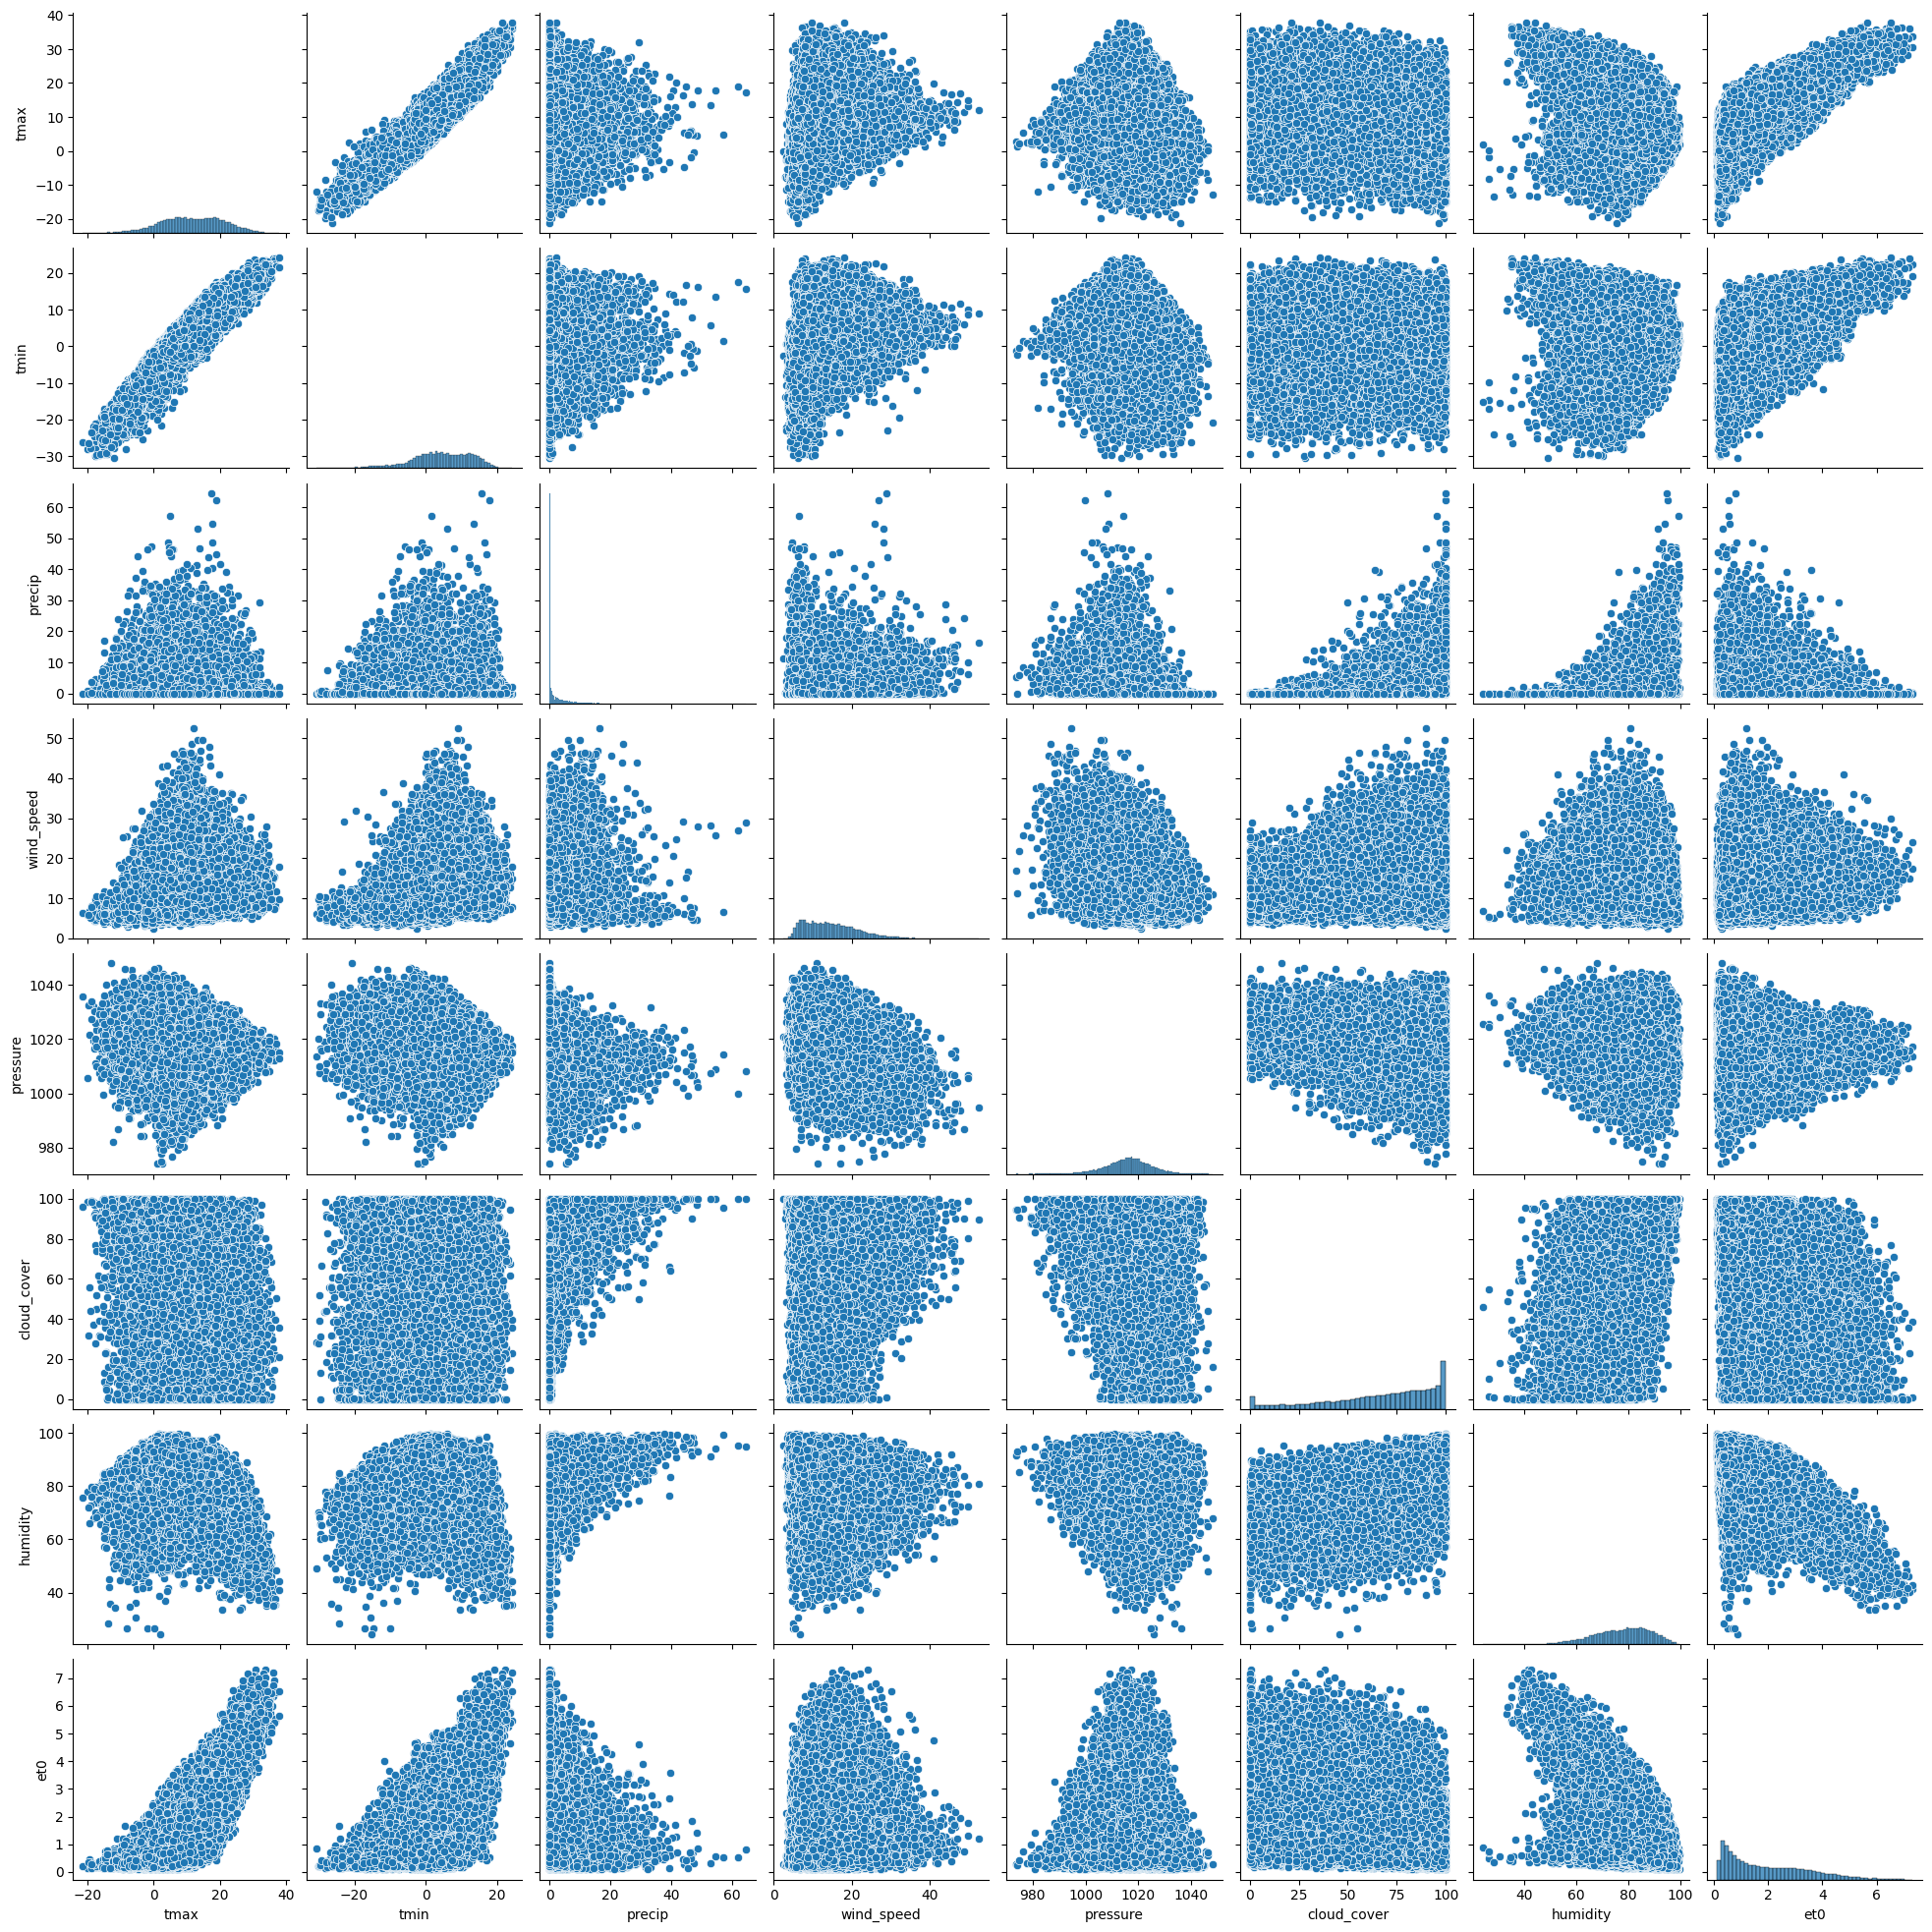

In [ ]:
# We use seaborn to inspect the training data
sns.pairplot(data_train[features[:-3]])

### Feature scaling

Next, we scale the features. There are different ways to do this. Here, we use **standard scaling**, which means that we standardize thefeatures by removing the mean and scaling to unit variance.
* [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html$0)

In [172]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## Training

Now, we look at different models for prediction. For training, we use the scaled training data.

### Evaluation

We create a custom evaluation function which we use to evaluate the models. At the moment, we only consider two metrics, **accuracy** and the **$F_1$ score**, and look at the classification report. Do a quick search what those metrics tell us. You can add also other metrics if you like!
* [Accuracy score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score$0)
* [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score$0)
* [Classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn.metrics.classification_report$0)
* [Classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics$0)

In [73]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [92]:
def evaluate(model_instance, y, y_pred, dataset_name, model_name):
  accuracy = accuracy_score(y, y_pred)
  f1 = f1_score(y, y_pred)
  report = classification_report(y, y_pred)
  print("=" * 60)
  print(f" {model_name}, {dataset_name}")
  print("=" * 60)
  print(f" Accuracy: {accuracy:.3f} \n F1 score: {f1:.3f} \n Classification report: \n {report} \n")



---



### **Logistic regression baseline**

Before testing out ML architectures, we start with a simple logistic regression baseline, which is essential to every ML workflow. More information:
* [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html$0)
* [Wikipedia](https://en.wikipedia.org/wiki/Logistic_regression#Supervised_machine_learning$0)

In [68]:
from sklearn.linear_model import LogisticRegression

In [70]:
# create model instance
logistic_regression = LogisticRegression()

In [71]:
# fit the model
logistic_regression.fit(X_train_scaled, y_train)

LogisticRegression()

In [76]:
# Make predictions
y_pred_train = logistic_regression.predict(X_train_scaled)
y_pred_val = logistic_regression.predict(X_val_scaled)

In [94]:
# Compute metrics using our custom function
evaluate(
    model_instance = logistic_regression,
    y = y_train,
    y_pred = y_pred_train,
    dataset_name = "Training",
    model_name = "Logistic regression"
)
evaluate(
    model_instance = logistic_regression,
    y = y_val,
    y_pred = y_pred_val,
    dataset_name = "Validation",
    model_name = "Logistic regression"
)

 Logistic regression, Training
 Accuracy: 0.692 
 F1 score: 0.553 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.72      0.82      0.77     17874
         1.0       0.63      0.49      0.55     11346

    accuracy                           0.69     29220
   macro avg       0.68      0.66      0.66     29220
weighted avg       0.68      0.69      0.68     29220
 

 Logistic regression, Validation
 Accuracy: 0.687 
 F1 score: 0.529 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.69      0.85      0.77      4379
         1.0       0.66      0.44      0.53      2926

    accuracy                           0.69      7305
   macro avg       0.68      0.65      0.65      7305
weighted avg       0.68      0.69      0.67      7305
 





---



### **Decision trees**

As you can see, logistic regression already is a good start. However, the relationships we are trying to model are often not linear.

Next, we look at decision trees. The steps are the same as for logistic regression. We start with a very shallow tree.
* [Decision trees](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.score$0)

In [98]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [101]:
decision_tree = DecisionTreeClassifier(max_depth=3) # shallow tree

In [102]:
decision_tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=3)

Let's first have a look at the tree. You can find more information here:
* [Plot tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html$0)
* [Understanding the decision tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html$0)
* [Gini impurity](https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity$0)

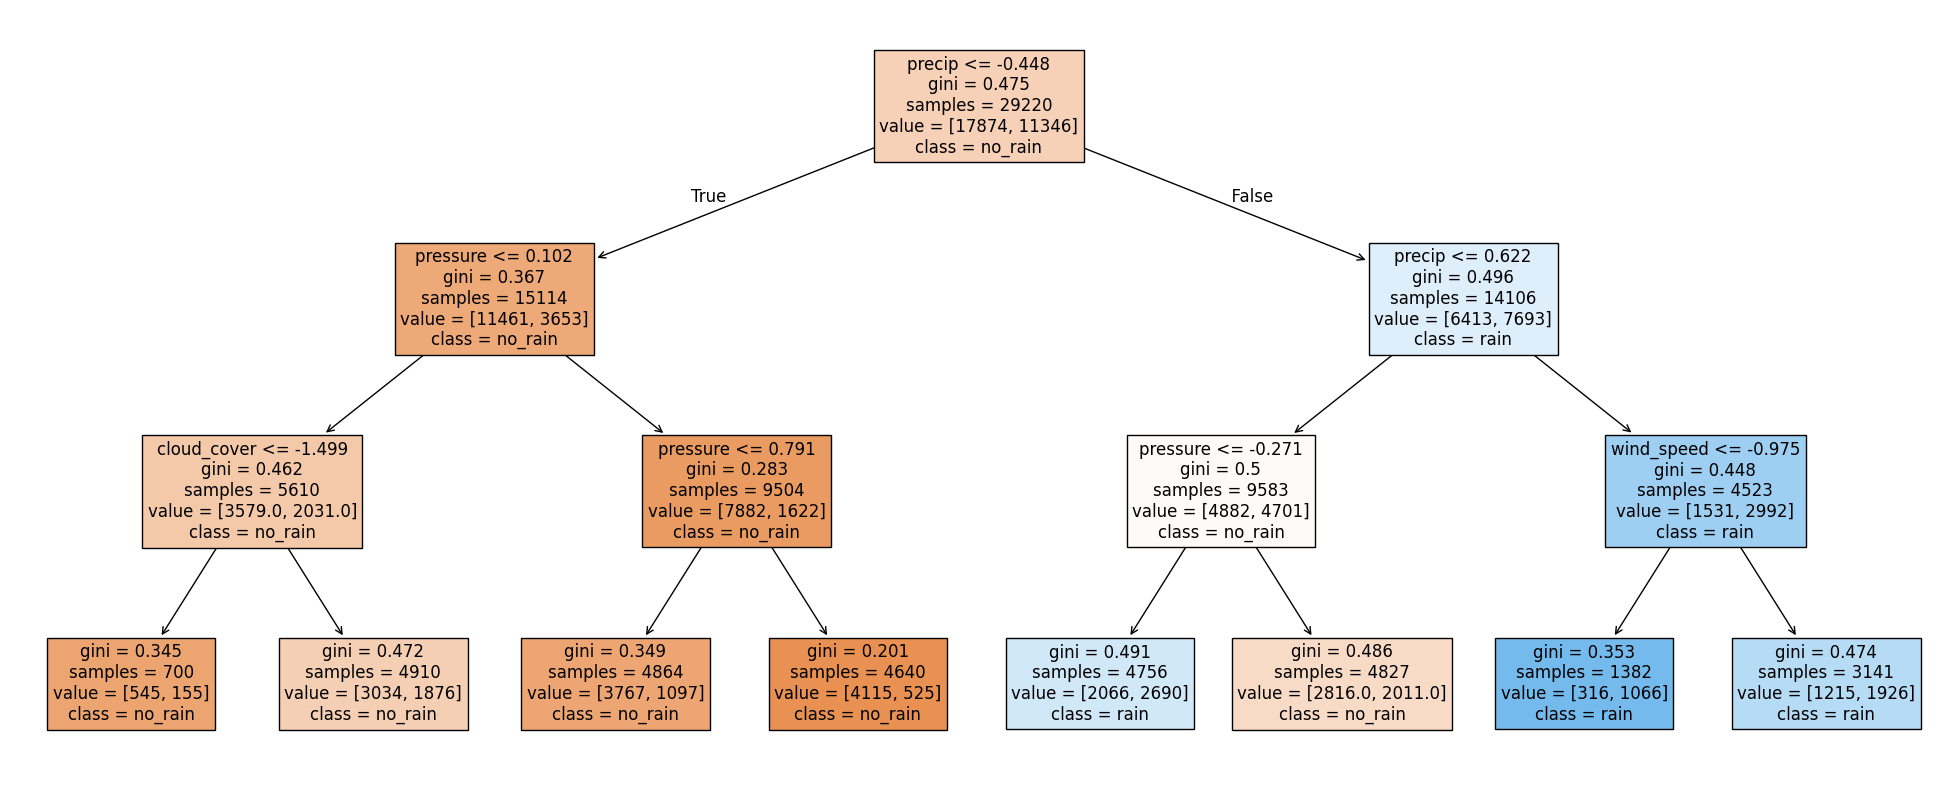

In [104]:
fig, ax = plt.subplots(figsize=(25, 10))
plot_tree(decision_tree, filled=True, ax=ax, fontsize=12, feature_names=X_train.columns, class_names=["no_rain", "rain"]);

Look at the tree in detail. Does it match your expectations?

### Compute a full tree

Our first tree was very shallow. To make predictions, we compute a full tree.

In [106]:
decision_tree = DecisionTreeClassifier() # full tree

In [107]:
decision_tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [108]:
# Make predictions
y_pred_train = decision_tree.predict(X_train_scaled)
y_pred_val = decision_tree.predict(X_val_scaled)

In [109]:
# Compute metrics using our custom function
evaluate(
    model_instance = decision_tree,
    y = y_train,
    y_pred = y_pred_train,
    dataset_name = "Training",
    model_name = "Decision tree"
)
evaluate(
    model_instance = decision_tree,
    y = y_val,
    y_pred = y_pred_val,
    dataset_name = "Validation",
    model_name = "Decision tree"
)

 Decision tree, Training
 Accuracy: 1.000 
 F1 score: 1.000 
 Classification report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17874
         1.0       1.00      1.00      1.00     11346

    accuracy                           1.00     29220
   macro avg       1.00      1.00      1.00     29220
weighted avg       1.00      1.00      1.00     29220
 

 Decision tree, Validation
 Accuracy: 0.593 
 F1 score: 0.495 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.66      0.66      0.66      4379
         1.0       0.49      0.50      0.50      2926

    accuracy                           0.59      7305
   macro avg       0.58      0.58      0.58      7305
weighted avg       0.59      0.59      0.59      7305
 



Do you notice something here?

You can see that we have perfect scores on the training set, but the scores on the validation set are not so good. This is a classic example of **overfitting**.

But this is to be expected. We built our tree to perfectly fit the training set, so that only one sample remains in the final leafs.

Therefore, we need to adjust the tree to prevent overfitting. This is a simple form of **hyperparameter tuning**.

Here, we reduce the complexity of the tree by increasing the number of samples in each leaf and setting the maximum depth of the tree. You can experiment here!

In [116]:
decision_tree = DecisionTreeClassifier(min_samples_leaf = 10, max_depth=5)
decision_tree.fit(X_train_scaled, y_train)
y_pred_train = decision_tree.predict(X_train_scaled)
y_pred_val = decision_tree.predict(X_val_scaled)
evaluate(
    model_instance = decision_tree,
    y = y_train,
    y_pred = y_pred_train,
    dataset_name = "Training",
    model_name = "Decision tree"
)
evaluate(
    model_instance = decision_tree,
    y = y_val,
    y_pred = y_pred_val,
    dataset_name = "Validation",
    model_name = "Decision tree"
)

 Decision tree, Training
 Accuracy: 0.693 
 F1 score: 0.565 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.72      0.81      0.76     17874
         1.0       0.63      0.51      0.57     11346

    accuracy                           0.69     29220
   macro avg       0.68      0.66      0.66     29220
weighted avg       0.69      0.69      0.69     29220
 

 Decision tree, Validation
 Accuracy: 0.682 
 F1 score: 0.548 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.70      0.82      0.75      4379
         1.0       0.64      0.48      0.55      2926

    accuracy                           0.68      7305
   macro avg       0.67      0.65      0.65      7305
weighted avg       0.68      0.68      0.67      7305
 





---



### **Random forests**

Going one step further, we will now implement a random forest. The idea behind random forests is to have many individual decision trees that are all a little different. At each split, only a random subset of features and samples is taken into account for deciding the best split. Because the errors of the individual trees will be independent from each other, averaging the prediction will reduce the error.
* [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html$0)

In [117]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators=100, random_state=42) # random forest

In [118]:
random_forest.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [119]:
# Make predictions
y_pred_train = random_forest.predict(X_train_scaled)
y_pred_val = random_forest.predict(X_val_scaled)

In [120]:
# Compute metrics using our custom function
evaluate(
    model_instance = random_forest,
    y = y_train,
    y_pred = y_pred_train,
    dataset_name = "Training",
    model_name = "Random forest"
)
evaluate(
    model_instance = random_forest,
    y = y_val,
    y_pred = y_pred_val,
    dataset_name = "Validation",
    model_name = "Random forest"
)

 Random forest, Training
 Accuracy: 1.000 
 F1 score: 1.000 
 Classification report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17874
         1.0       1.00      1.00      1.00     11346

    accuracy                           1.00     29220
   macro avg       1.00      1.00      1.00     29220
weighted avg       1.00      1.00      1.00     29220
 

 Random forest, Validation
 Accuracy: 0.690 
 F1 score: 0.543 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.70      0.84      0.77      4379
         1.0       0.66      0.46      0.54      2926

    accuracy                           0.69      7305
   macro avg       0.68      0.65      0.65      7305
weighted avg       0.69      0.69      0.68      7305
 



Again, we see overfitting and have to tune the hyperparameters. Try this out yourself! If you want, you can also try to implement a random search that automatically tests different combinations of hyperparameters.

In [126]:
random_forest = RandomForestClassifier(n_estimators=100, n_jobs=-1, min_samples_leaf=20)
random_forest.fit(X_train_scaled, y_train)
y_pred_train = random_forest.predict(X_train_scaled)
y_pred_val = random_forest.predict(X_val_scaled)
evaluate(
    model_instance = random_forest,
    y = y_train,
    y_pred = y_pred_train,
    dataset_name = "Training",
    model_name = "Random forest"
)
evaluate(
    model_instance = random_forest,
    y = y_val,
    y_pred = y_pred_val,
    dataset_name = "Validation",
    model_name = "Random forest"
)

 Random forest, Training
 Accuracy: 0.779 
 F1 score: 0.688 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.79      0.88      0.83     17874
         1.0       0.76      0.63      0.69     11346

    accuracy                           0.78     29220
   macro avg       0.78      0.75      0.76     29220
weighted avg       0.78      0.78      0.77     29220
 

 Random forest, Validation
 Accuracy: 0.696 
 F1 score: 0.546 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.70      0.86      0.77      4379
         1.0       0.68      0.46      0.55      2926

    accuracy                           0.70      7305
   macro avg       0.69      0.66      0.66      7305
weighted avg       0.69      0.70      0.68      7305
 



#### Confusion matrix

To get a better understanding of model performance, we can also look at the confusion matrix:
* [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html$0)


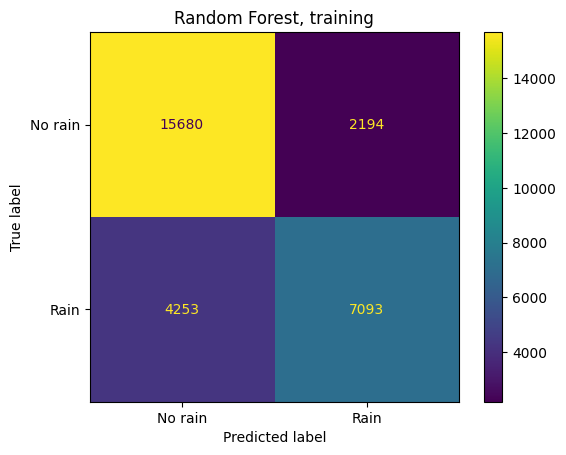

In [137]:
ConfusionMatrixDisplay.from_estimator(random_forest, X_train_scaled, y_train, display_labels=["No rain", "Rain"])
plt.title("Random Forest, training")
plt.show()

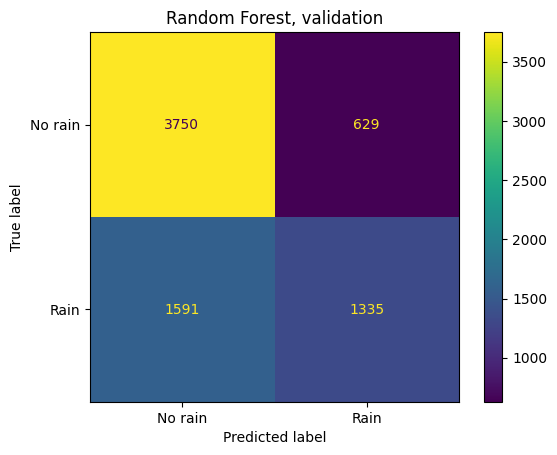

In [138]:
ConfusionMatrixDisplay.from_estimator(random_forest, X_val_scaled, y_val, display_labels=["No rain", "Rain"])
plt.title("Random Forest, validation")
plt.show()

#### Feature importances

We do not only want a prediction that yields high metric scores. Ideally, we also want to understand **why** we are getting the prediction.

One way to do this is to look at feature importance, which tells us about the importance of individual features for the final prediciton. Two common methods to identify important features are permutation importance and the Gini importance.

In permutation importance, each column of the dataset is randomly shuffled. Then, we check by how much the prediction skill decreases. This is simply a measure of how important each input feature is for making a good prediction. In other words, without this feature how much worse would the prediction get?

Gini importance calculates each features importance as the sum over the number of splits (across all tress) that include the feature, proportionally to the number of samples it splits.

In [127]:
from sklearn.inspection import permutation_importance

In [128]:
permutation_importance(random_forest, X_train_scaled, y_train, n_repeats=1, n_jobs=-1)

{'importances_mean': array([0.02727584, 0.03104038, 0.06084873, 0.04086242, 0.083436  ,
        0.04839151, 0.02446954, 0.03600274, 0.0196783 , 0.01512663,
        0.01232033]),
 'importances_std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'importances': array([[0.02727584],
        [0.03104038],
        [0.06084873],
        [0.04086242],
        [0.083436  ],
        [0.04839151],
        [0.02446954],
        [0.03600274],
        [0.0196783 ],
        [0.01512663],
        [0.01232033]])}

In [129]:
random_forest.feature_importances_

array([0.06170012, 0.06384168, 0.18644264, 0.0883261 , 0.2034618 ,
       0.10789576, 0.06088909, 0.06823408, 0.10135876, 0.02775033,
       0.03009964])

In [131]:
# Create a dataframe for plotting
importances_df = pd.DataFrame(
    data={'Feature': X_train.columns, 'Feature importance': random_forest.feature_importances_},
    columns = ['Feature', 'Feature importance']
)
importances_df.sort_values('Feature importance', inplace=True, ascending=False)

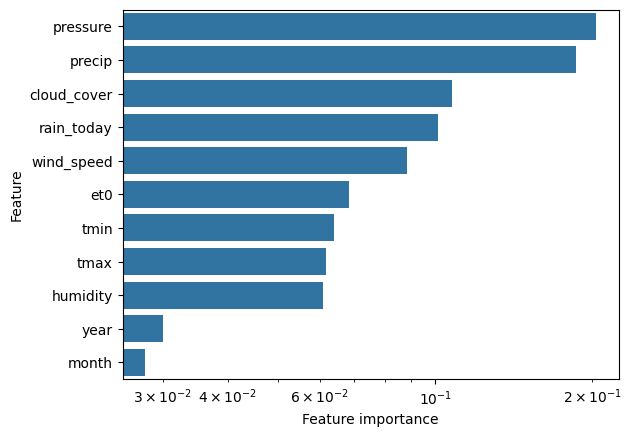

In [132]:
sns.barplot(data=importances_df, x='Feature importance', y='Feature')
plt.xscale('log')

What do the results tell you? Are they what you expected?

#### **Evaluation per city**

Finally, after tuning the hyperparameters of our random forest model, we want to evaluate how the model performs for each city, using the test set.

In [173]:
data_test["prediction"] = random_forest.predict(X_test_scaled)
# data_test = data_test.dropna()

for city, group in data_test.groupby("location"):
  f1 = f1_score(group["rain_tomorrow"], group["prediction"])
  accuracy = accuracy_score(group["rain_tomorrow"], group["prediction"])
  print(f"{city:20s} Accuracy: {accuracy:.2f}, F1 score: {f1:.2f}")


Berlin               Accuracy: 0.71, F1 score: 0.50
Hamburg              Accuracy: 0.70, F1 score: 0.58
Innsbruck            Accuracy: 0.69, F1 score: 0.69
Karlsruhe            Accuracy: 0.71, F1 score: 0.53
Leipzig              Accuracy: 0.71, F1 score: 0.51


### **Neural network**

Finally, we want to train a neural network. For this, we use the **PyTorch** library.

* [PyTorch Tutorial and documentation](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html$0)

In [149]:
import torch
import torch.nn as nn

First, we create the model class ```RainNN```. Then, we use ```torch.tensor``` for our datasets, so that they are in the correct format for the NN model class. Finally, we implement the training loop. As the loss function, we use the ```BCELoss``` and the Adam optimizer.
* [BCELoss](https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCELoss.html$0)
* [Pytorch optimizer information](https://docs.pytorch.org/docs/2.12/optim.html$0)
* [Adam optimizer](https://docs.pytorch.org/docs/2.12/generated/torch.optim.Adam.html#torch.optim.Adam$0)

In [150]:
# model class
class RainNN(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.NN = nn.Sequential(
        nn.Linear(n_features, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )
  def forward(self, x):
    return self.NN(x).squeeze()

In [175]:
# PyTorch tensors
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.to_numpy(), dtype=torch.float32)

In [155]:

model = RainNN(X_train_torch.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

for epoch in range(100): # we train for 100 epochs
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(X_train_torch), y_train_torch)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 — Loss: {loss.item():.4f}")

Epoch 10/100 — Loss: 0.6628
Epoch 20/100 — Loss: 0.6389
Epoch 30/100 — Loss: 0.6181
Epoch 40/100 — Loss: 0.6022
Epoch 50/100 — Loss: 0.5930
Epoch 60/100 — Loss: 0.5894
Epoch 70/100 — Loss: 0.5846
Epoch 80/100 — Loss: 0.5825
Epoch 90/100 — Loss: 0.5800
Epoch 100/100 — Loss: 0.5765


If you still have time, you could try to visualize the learning curve. This is very helpful for detecting overfitting!

Finally, we make predictions. For this, we again have to create tensors. Then, we have to set the model to evaluation mode, this disables dropout, which is only active during training. Our model ends with a sigmoid, so it already outputs a probability between 0 and 1. Bacuse of this, we convert the probabilities to classes at the end. ```torch.no_grad()``` is important. Without it, PyTorch still tracks gradients, which wastes memory and time.

Here, we are making predictions on all datasets. If you still have enough time, you could do some hyperparameter tuning first.

In [174]:
# PyTorch tensors
X_val_torch = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_torch = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

# We create a small prediction function
def predict_nn(model, X, y):
  model.eval()
  with torch.no_grad():
    y_prob = model(X).numpy()  # predicted probabilities

  # Convert probabilities to binary labels using 0.5 as the threshold
  y_pred = (y_prob >= 0.5).astype(int)
  return y_prob, y_pred

y_prob_train, y_pred_train = predict_nn(model=model, X=X_train_torch, y=y_train_torch)
y_prob_val, y_pred_val = predict_nn(model=model, X=X_val_torch, y=y_val_torch)
y_prob_test, y_pred_test = predict_nn(model=model, X=X_test_torch, y=y_test_torch)

In [176]:
# Compute metrics using our custom function
evaluate(
    model_instance = model,
    y = y_train,
    y_pred = y_pred_train,
    dataset_name = "Training",
    model_name = "Neural network"
)
evaluate(
    model_instance = model,
    y = y_val,
    y_pred = y_pred_val,
    dataset_name = "Validation",
    model_name = "Neural network"
)
evaluate(
    model_instance = model,
    y = y_test,
    y_pred = y_pred_test,
    dataset_name = "Test",
    model_name = "Neural network"
)

 Neural network, Training
 Accuracy: 0.698 
 F1 score: 0.584 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.73      0.79      0.76     17874
         1.0       0.63      0.55      0.58     11346

    accuracy                           0.70     29220
   macro avg       0.68      0.67      0.67     29220
weighted avg       0.69      0.70      0.69     29220
 

 Neural network, Validation
 Accuracy: 0.690 
 F1 score: 0.556 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.71      0.83      0.76      4379
         1.0       0.65      0.48      0.56      2926

    accuracy                           0.69      7305
   macro avg       0.68      0.66      0.66      7305
weighted avg       0.69      0.69      0.68      7305
 

 Neural network, Test
 Accuracy: 0.699 
 F1 score: 0.573 
 Classification report: 
               precision    recall  f1-score   support

         0.0       0.71  

#### Inspect the probabilites

One advantage of a neural network over a simple threshold classifier is that the probabilities are more informative than simple classes

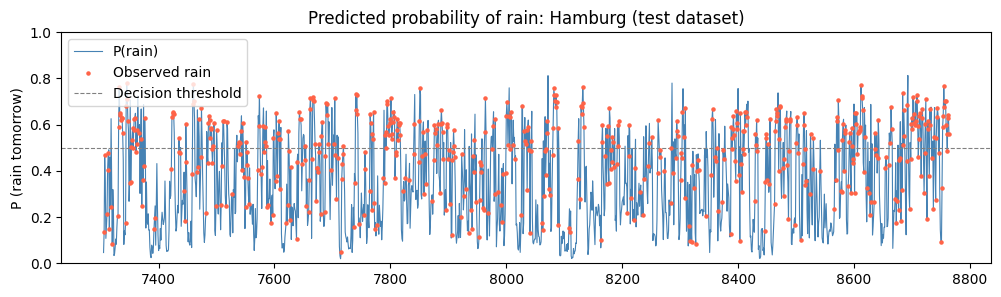

In [182]:
data_test_final = X_test.copy()
data_test_final["observed"] = y_test.values
data_test_final["probability"] = y_prob_test
data_test_final["predicted"] = y_pred_test

# Plot predicted probability for a single city
city_mask = data_test["location"].values == "Hamburg"

plt.figure(figsize=(12, 3))
plt.plot(data_test_final.loc[city_mask, "probability"], color="steelblue", linewidth=0.8, label="P(rain)")
plt.scatter(
    data_test_final.index[city_mask & (data_test_final["observed"] == 1)],
    data_test_final.loc[city_mask & (data_test_final["observed"] == 1), "probability"],
    color="tomato", s=5, label="Observed rain", zorder=3
)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Decision threshold")
plt.legend()
plt.title("Predicted probability of rain: Hamburg (test dataset)")
plt.ylabel("P (rain tomorrow)")
plt.ylim(0, 1)
plt.show()


#### Make a prediction for a new day

You can experiment here! Maybe you can find out the values for today or yesterday and see what the model predicts?

In [187]:
new_day = pd.DataFrame([{
    "tmax": 22.0,
    "tmin": 15.0,
    "tmean": 18.0,
    "precip": 0.0,   # dry today
    "wind_speed": 8.0,
    "pressure": 1005.0,  # slightly low
    "cloud_cover": 0.8,   # very cloudy
    "humidity": 85.0,
    "et0": 0.55,
    "rain_today": 1,
    "month": 5,
    "year": 2026,
}])

new_day_scaled = scaler.transform(new_day[features])
new_tensor = torch.tensor(new_day_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    prob = model(new_tensor).item()

print(f"Predicted probability of rain tomorrow: {prob:.1%}")
print(f"Decision: {'Rain expected' if prob >= 0.5 else 'No rain expected'}")


Predicted probability of rain tomorrow: 16.5%
Decision: No rain expected
